# Battery 불량 탐지 - ResNet50 전이학습 (Transfer Learning)

**목표**: ImageNet으로 사전 학습된 ResNet50을 활용하여 배터리 불량을 탐지합니다.

**전이학습이란?**
- 수백만 장의 ImageNet 이미지로 학습된 ResNet50의 특징 추출 능력을 가져옵니다.
- 우리 데이터(배터리)에 맞게 마지막 분류 레이어만 새로 학습합니다.
- 데이터가 적거나 학습 시간을 줄이고 싶을 때 매우 효과적입니다.

**ResNet50이란?**
- 50개 레이어로 구성된 깊은 CNN 모델
- Residual Connection(잔차 연결)으로 깊어도 기울기 소실 문제를 해결
- 2015년 ImageNet 대회 우승 모델

**2단계 Fine-tuning 전략:**
- 1단계: ResNet50 가중치 동결 -> 분류기(우리 레이어)만 학습
- 2단계: 상위 레이어 일부 동결 해제 -> 전체 미세조정

---
> **메모리**: tf.data 파이프라인 방식으로 RAM 부족 없이 실행됩니다.
> **CPU 환경**: EPOCHS를 3~5로 줄여 테스트해 보세요.

In [1]:
# ==============================================================
# [셀 1] 라이브러리 임포트 및 경로 설정
# ==============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from glob import glob

ROOT      = os.path.join(os.getcwd(), 'dataset', 'battery_subset_binary_train10000')
IMAGE_DIR = os.path.join(ROOT, 'images')
MODEL_DIR = os.path.join(os.getcwd(), 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS_1   = 5     # 1단계: 분류기만 학습
EPOCHS_2   = 5     # 2단계: Fine-tuning

print('데이터셋 루트:', ROOT)
print('모델 저장 폴더:', MODEL_DIR)

데이터셋 루트: d:\DeepLearning\dataset\battery_subset_binary_train10000
모델 저장 폴더: d:\DeepLearning\model


In [2]:
# ==============================================================
# [셀 2] CSV 로드 + tf.data 파이프라인 구성 (ResNet50 전용)
# ==============================================================
# [메모리 절약] tf.data 파이프라인 사용
#   - 이미지를 RAM에 한꺼번에 올리지 않고 배치 단위로 읽습니다.
#
# ResNet50 전용 전처리 (preprocess_input):
#   - 단순 /255.0 정규화가 아닌 ImageNet 평균을 빼는 방식
#   - ResNet50이 ImageNet 학습 시 사용한 것과 동일한 전처리
#   - 반드시 ResNet50용 preprocess_input을 사용해야 합니다!
# ==============================================================

from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# CSV 로드 및 경로 생성
train_df = pd.read_csv(os.path.join(ROOT, 'train.csv'))
valid_df  = pd.read_csv(os.path.join(ROOT, 'valid.csv'))



for df in [train_df, valid_df]:
    df['new_relative_path'] = df['new_relative_path'].str.replace('\\', '/', regex=False)
    df['image_path']   = df['new_relative_path'].apply(lambda x: os.path.join(ROOT, x))
    df['image_exists'] = df['image_path'].apply(lambda p: os.path.exists(p) and os.path.getsize(p) > 0)
    df['label_num']    = df['binary_label'].map({'normal': 0, 'defect': 1})

train_df = train_df[train_df['image_exists']].copy()
valid_df  = valid_df[valid_df['image_exists']].copy()

print(f'train: {len(train_df)}장, valid: {len(valid_df)}장')

train_paths  = train_df['image_path'].tolist()
train_labels = train_df['label_num'].tolist()
valid_paths  = valid_df['image_path'].tolist()
valid_labels = valid_df['label_num'].tolist()


def load_and_preprocess_resnet(path, label):
    """
    ResNet50 전용 이미지 로더.
    - tf.io.read_file: 디스크에서 파일 읽기
    - tf.image.decode_image: 이미지 디코딩
    img.set_shape([None, None, 3])
    - tf.image.resize: 224x224 리사이즈
    - resnet_preprocess: ImageNet 기준 정규화 (채널별 평균 빼기)
    """
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = resnet_preprocess(img)  # ResNet50 전용 정규화
    return img, label


# tf.data 파이프라인 구성
train_dataset = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .shuffle(len(train_paths), seed=42)
    .map(load_and_preprocess_resnet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
valid_dataset = (
    tf.data.Dataset.from_tensor_slices((valid_paths, valid_labels))
    .map(load_and_preprocess_resnet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# 샘플 확인
sample_imgs, sample_lbls = next(iter(train_dataset))
print('샘플 배치 shape:', sample_imgs.shape)
print('라벨 분포 - train normal:', train_labels.count(0), '/ defect:', train_labels.count(1))

train: 7982장, valid: 1997장
샘플 배치 shape: (16, 224, 224, 3)
라벨 분포 - train normal: 4000 / defect: 3982


In [3]:
# ==============================================================
# [셀 3] ResNet50 모델 구성 (Transfer Learning)
# ==============================================================
# 전이학습 모델 구성 방법:
#
#   1. ResNet50 베이스 로드:
#      - weights='imagenet' : ImageNet으로 사전 학습된 가중치 사용
#      - include_top=False  : 최상단 분류 레이어(1000 클래스) 제외
#      - pooling='avg'      : Global Average Pooling 적용
#                             (이미지 크기에 무관하게 고정 크기 벡터 출력)
#
#   2. 분류 헤드 추가:
#      - Dense(128, relu)   : ResNet 특징을 우리 데이터에 맞게 변환
#      - Dropout(0.3)       : 과적합 방지
#      - Dense(1, sigmoid)  : 이진 분류 출력
# ==============================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# ResNet50 베이스 로드 (첫 실행 시 ~100MB 다운로드)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# 1단계: ResNet50 전체 동결
base_model.trainable = False

# 분류 헤드 추가
x = base_model.output
x = Dense(128, activation='relu', name='classifier_dense')(x)
x = Dropout(0.3, name='classifier_dropout')(x)
output = Dense(1, activation='sigmoid', name='classifier_output')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)

print(f'전체 레이어 수: {len(model_resnet.layers)}')
print(f'전체 파라미터: {model_resnet.count_params():,}')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 40s 0us/step
전체 레이어 수: 179
전체 파라미터: 23,850,113


In [4]:
# ==============================================================
# [셀 4] 1단계 학습: 분류기(헤드)만 학습
# ==============================================================
# 왜 2단계로 나눠서 학습하나?
#
#   1단계 (현재 셀):
#     - ResNet50 가중치를 동결하고 분류 헤드만 학습
#     - ResNet50은 이미 좋은 특징을 추출하므로 분류기가 이에 적응
#     - 이 과정 없이 바로 전체 학습하면 무작위 초기화된 헤드가
#       ResNet50의 학습된 가중치를 망가뜨릴 수 있음
#
#   2단계 (다음 셀):
#     - 분류기가 안정화된 후 ResNet50 상위 레이어를 열어서 미세 조정
# ==============================================================

model_resnet.compile(
    optimizer=Adam(learning_rate=0.001),  # 1단계는 높은 학습률
    loss='binary_crossentropy',
    metrics=['accuracy']
)

checkpoint_1 = ModelCheckpoint(
    os.path.join(MODEL_DIR, 'battery_resnet_stage1_best.keras'),
    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)
early_stop_1 = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

print('=== 1단계 학습: 분류기(헤드)만 학습 ===')
history_1 = model_resnet.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS_1,
    callbacks=[checkpoint_1, early_stop_1]
)

print('\n1단계 완료! 검증 정확도:', max(history_1.history['val_accuracy']))

=== 1단계 학습: 분류기(헤드)만 학습 ===
Epoch 1/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.9601 - loss: 0.1329
Epoch 1: val_accuracy improved from -inf to 0.98448, saving model to d:\DeepLearning\model\battery_resnet_stage1_best.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 534s 1s/step - accuracy: 0.9601 - loss: 0.1328 - val_accuracy: 0.9845 - val_loss: 0.0704
Epoch 2/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 815ms/step - accuracy: 0.9845 - loss: 0.0636
Epoch 2: val_accuracy did not improve from 0.98448
499/499 ━━━━━━━━━━━━━━━━━━━━ 504s 1s/step - accuracy: 0.9845 - loss: 0.0636 - val_accuracy: 0.9845 - val_loss: 0.0510
Epoch 3/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9868 - loss: 0.0510
Epoch 3: val_accuracy did not improve from 0.98448
499/499 ━━━━━━━━━━━━━━━━━━━━ 491s 984ms/step - accuracy: 0.9868 - loss: 0.0510 - val_accuracy: 0.9845 - val_loss: 0.0627
Epoch 4/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 841ms/step - accuracy: 0.9860 - loss: 0.0433
Epoch 4: val_accuracy improved from 0.984

In [5]:
# ==============================================================
# [셀 5] 2단계 Fine-tuning: 상위 레이어 일부 동결 해제
# ==============================================================
# Fine-tuning 전략:
#   - ResNet50 총 175개 레이어
#   - 하위 레이어: 엣지, 색상 등 일반적 특징 -> 동결 유지
#   - 상위 레이어: 복잡한 추상 특징 -> 해제하여 배터리 데이터에 적응
#   - BatchNorm은 항상 동결 (학습 불안정 방지)
# ==============================================================

from tensorflow.keras.layers import BatchNormalization

UNFREEZE_FROM = 100

for layer in model_resnet.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
    elif model_resnet.layers.index(layer) >= UNFREEZE_FROM:
        layer.trainable = True

# Fine-tuning 시 학습률 1/10 (기존 가중치 보호)
model_resnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f'학습 가능 레이어: {sum(1 for l in model_resnet.layers if l.trainable)} / {len(model_resnet.layers)}')

checkpoint_2 = ModelCheckpoint(
    os.path.join(MODEL_DIR, 'battery_resnet_finetune_best.keras'),
    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)
early_stop_2 = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

print('=== 2단계 Fine-tuning 시작 ===')
history_2 = model_resnet.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS_2,
    callbacks=[checkpoint_2, early_stop_2]
)

print('\n2단계 완료! 검증 정확도:', max(history_2.history['val_accuracy']))

학습 가능 레이어: 56 / 179
=== 2단계 Fine-tuning 시작 ===
Epoch 1/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9790 - loss: 0.1028
Epoch 1: val_accuracy improved from -inf to 0.98448, saving model to d:\DeepLearning\model\battery_resnet_finetune_best.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 898s 2s/step - accuracy: 0.9790 - loss: 0.1028 - val_accuracy: 0.9845 - val_loss: 0.0677
Epoch 2/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9848 - loss: 0.0664
Epoch 2: val_accuracy did not improve from 0.98448
499/499 ━━━━━━━━━━━━━━━━━━━━ 888s 2s/step - accuracy: 0.9848 - loss: 0.0664 - val_accuracy: 0.9845 - val_loss: 0.0584
Epoch 3/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9828 - loss: 0.0688
Epoch 3: val_accuracy did not improve from 0.98448
499/499 ━━━━━━━━━━━━━━━━━━━━ 875s 2s/step - accuracy: 0.9828 - loss: 0.0688 - val_accuracy: 0.9845 - val_loss: 0.0525
Epoch 4/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9861 - loss: 0.0484
Epoch 4: val_accuracy did not impro

125/125 ━━━━━━━━━━━━━━━━━━━━ 99s 791ms/step - accuracy: 0.9833 - loss: 0.0423

=== 최종 검증 결과 ===
검증 손실: 0.0433
검증 정확도: 0.9845

=== Confusion Matrix ===
[[969  31]
 [  0 997]]

=== Classification Report ===
              precision    recall  f1-score   support

      normal       1.00      0.97      0.98      1000
      defect       0.97      1.00      0.98       997

    accuracy                           0.98      1997
   macro avg       0.98      0.98      0.98      1997
weighted avg       0.98      0.98      0.98      1997



C:\Users\human-12\AppData\Local\Temp\ipykernel_10552\2396265968.py:54: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human-12\AppData\Local\Temp\ipykernel_10552\2396265968.py:54: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human-12\AppData\Local\Temp\ipykernel_10552\2396265968.py:55: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(MODEL_DIR, 'resnet_training_curve.png'), dpi=150)
C:\Users\human-12\AppData\Local\Temp\ipykernel_10552\2396265968.py:55: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(MODEL_DIR, 'resnet_training_curve.png'), dpi=150)
d:\DeepLearning\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

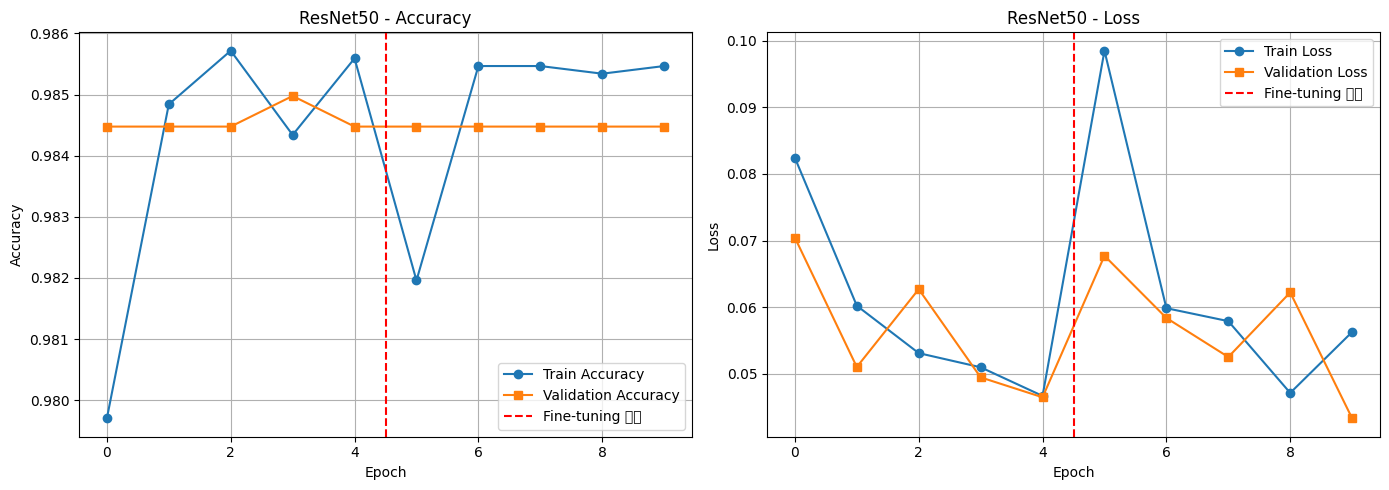

학습 곡선 저장 완료


In [6]:
# ==============================================================
# [셀 6] 최종 평가 및 시각화
# ==============================================================

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

loss, acc = model_resnet.evaluate(valid_dataset)
print('\n=== 최종 검증 결과 ===')
print('검증 손실:', round(loss, 4))
print('검증 정확도:', round(acc, 4))

# 배치 단위로 예측 수집
y_prob_list, y_true_list = [], []
for batch_imgs, batch_lbls in valid_dataset:
    preds = model_resnet.predict_on_batch(batch_imgs)
    y_prob_list.append(preds.reshape(-1))
    y_true_list.append(batch_lbls.numpy())

y_prob = np.concatenate(y_prob_list)
y_true = np.concatenate(y_true_list)
y_pred = (y_prob >= 0.5).astype(int)

print('\n=== Confusion Matrix ===')
print(confusion_matrix(y_true, y_pred))

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=['normal', 'defect']))

# 1단계 + 2단계 학습 곡선 합쳐서 시각화
acc_all     = history_1.history['accuracy']     + history_2.history['accuracy']
val_acc_all = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
loss_all    = history_1.history['loss']         + history_2.history['loss']
val_loss_all= history_1.history['val_loss']     + history_2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc_all,     label='Train Accuracy', marker='o')
axes[0].plot(val_acc_all, label='Validation Accuracy', marker='s')
axes[0].axvline(x=len(history_1.history['accuracy'])-0.5,
                color='red', linestyle='--', label='Fine-tuning 시작')
axes[0].set_title('ResNet50 - Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(loss_all,     label='Train Loss', marker='o')
axes[1].plot(val_loss_all, label='Validation Loss', marker='s')
axes[1].axvline(x=len(history_1.history['loss'])-0.5,
                color='red', linestyle='--', label='Fine-tuning 시작')
axes[1].set_title('ResNet50 - Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)


plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'resnet_training_curve.png'), dpi=150)
plt.show()
print('학습 곡선 저장 완료')

In [ ]:
# ==============================================================
# [셀 7] 최종 모델 저장
# ==============================================================

save_path = os.path.join(MODEL_DIR, 'battery_resnet_final.keras')
model_resnet.save(save_path)
print('ResNet50 최종 모델 저장 완료:', save_path)

print('\n저장된 모델 파일:')
for f in os.listdir(MODEL_DIR):
    if f.endswith('.keras'):
        size = os.path.getsize(os.path.join(MODEL_DIR, f)) / (1024 * 1024)
        print(f'  {f}  ({size:.1f} MB)')

ResNet50 최종 모델 저장 완료: d:\DeepLearning\model\battery_resnet_final.keras

저장된 모델 파일:
  battery_cnn_best.keras  (127.9 MB)
  battery_cnn_local_best.keras  (127.9 MB)
  battery_cnn_local_final.keras  (127.9 MB)
  battery_efficientnet_final.keras  (43.0 MB)
  battery_efficientnet_finetune_best.keras  (43.0 MB)
  battery_efficientnet_stage1_best.keras  (18.1 MB)
  battery_model_fixed.keras  (94.2 MB)
  battery_resnet_final.keras  (241.8 MB)
  battery_resnet_finetune_best.keras  (241.8 MB)
  battery_resnet_stage1_best.keras  (93.6 MB)


: 